# 02 — Non-Linear Integrate-and-Fire: Replacing the Hard Threshold

**Goal of this notebook.** LIF's threshold is a modeling convenience, not a mechanism — real spike initiation is driven by the fast, strongly voltage-dependent activation of sodium channels, which behaves much more like an *exponential* acceleration than a hard cutoff. This notebook explores the exponential nonlinearity introduced by Brette & Gerstner (2005) as the **v**-equation of the AdEx model — used here with its adaptation current switched off (`a=0, b=0`), which reduces it to the plain **Exponential Integrate-and-Fire (EIF)** neuron:

$$C_m \frac{dv}{dt} = -g_L(v - E_L) + g_L \Delta_T \exp\!\left(\frac{v - v_T}{\Delta_T}\right) + I(t)$$

We compare it directly against LIF throughout, and revisit the Euler-vs-RK4 question from Notebook 01 — this time for dynamics with a genuine nonlinearity.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

from src.neuron_models import LIFNeuron, AdExNeuron

%matplotlib inline

mpl.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

COLOR_LIF = "#a0aec0"
COLOR_EIF = "#2b6cb0"
COLOR_TH = "#dd6b20"


def make_eif(delta_T=2.0, **kwargs):
    '''An EIF neuron is just an AdExNeuron with adaptation switched off.'''
    params = dict(a=0.0, b=0.0, delta_T=delta_T)
    params.update(kwargs)
    return AdExNeuron(**params)


## 1. The exponential term, up close

$\Delta_T$ ("threshold slope factor") controls how sharply the exponential term turns on. As $\Delta_T \to 0$, the exponential term becomes a step function at $v_T$ — recovering something very close to LIF's hard threshold. Larger $\Delta_T$ gives a softer, more gradual spike initiation.

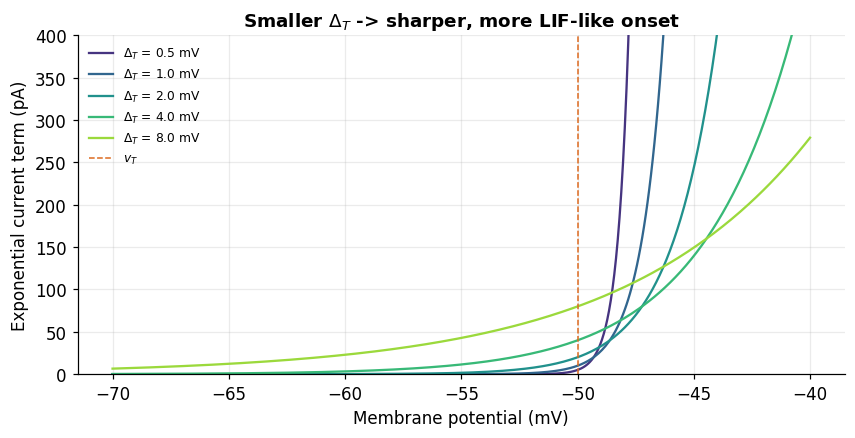

In [2]:
v_range = np.linspace(-70, -40, 400)
g_L, v_T = 10.0, -50.0

fig, ax = plt.subplots()
delta_Ts = [0.5, 1.0, 2.0, 4.0, 8.0]
colors = cm.viridis(np.linspace(0.15, 0.85, len(delta_Ts)))
for dT, c in zip(delta_Ts, colors):
    i_exp = g_L * dT * np.exp(np.clip((v_range - v_T) / dT, -50, 50))
    ax.plot(v_range, i_exp, color=c, label=f"$\\Delta_T$ = {dT} mV")

ax.axvline(v_T, color=COLOR_TH, ls="--", lw=1, label="$v_T$")
ax.set_ylim(0, 400)
ax.set_xlabel("Membrane potential (mV)")
ax.set_ylabel("Exponential current term (pA)")
ax.set_title("Smaller $\\Delta_T$ -> sharper, more LIF-like onset")
ax.legend(fontsize=8)
plt.show()


## 2. Voltage trajectories: LIF vs EIF

The clearest way to see the difference is to watch a spike happen. LIF's trace hits threshold and is instantly clipped; EIF's trace visibly *accelerates* — curving upward under its own nonlinearity — before the numerical cutoff (`v_peak`) is reached.

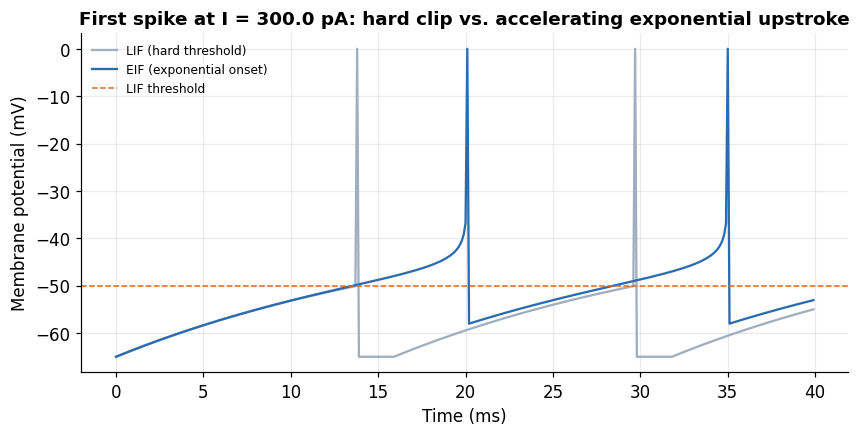

In [3]:
lif = LIFNeuron()
eif = make_eif(delta_T=2.0)

I_test = 300.0
res_lif = lif.simulate(I_ext=I_test, T=40.0)
res_eif = eif.simulate(I_ext=I_test, T=40.0)

fig, ax = plt.subplots()
ax.plot(res_lif["t"], res_lif["v"], color=COLOR_LIF, label="LIF (hard threshold)")
ax.plot(res_eif["t"], res_eif["v"], color=COLOR_EIF, label="EIF (exponential onset)")
ax.axhline(lif.v_th, color=COLOR_TH, ls="--", lw=1, label="LIF threshold")
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Membrane potential (mV)")
ax.set_title(f"First spike at I = {I_test} pA: hard clip vs. accelerating exponential upstroke")
ax.legend(fontsize=8)
plt.show()


## 3. Rheobase shifts because the exponential term is not zero *below* $v_T$

LIF's rheobase is the exact algebraic quantity $g_L(v_{th}-v_{rest})$. EIF has no such clean formula — the exponential current already contributes a little depolarizing drive even below $v_T$, which (for equal $v_T = v_{th}$) works out to a **lower** rheobase than the equivalent LIF neuron.

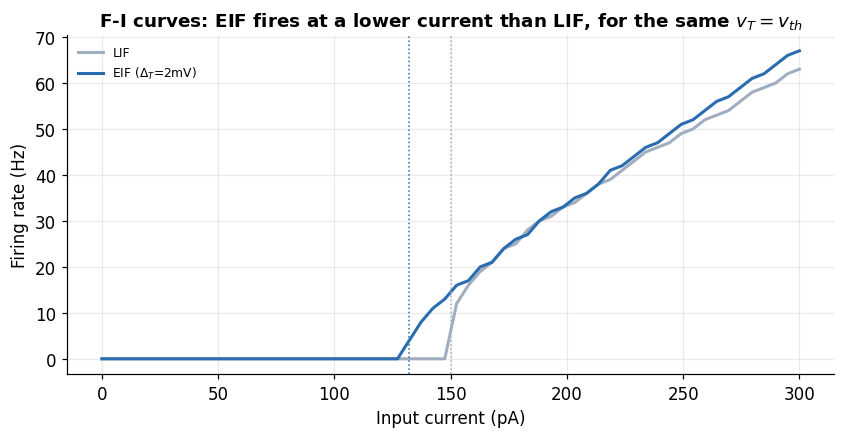

LIF rheobase (exact):        150 pA
EIF rheobase (approx, scan): 132 pA


In [4]:
rheobase_lif = lif.g_L * (lif.v_th - lif.v_rest)

I_scan = np.linspace(0, 300, 60)
rates_lif = lif.f_i_curve(I_scan, T=1200.0, transient=200.0)
rates_eif = eif.f_i_curve(I_scan, T=1200.0, transient=200.0)

# empirical EIF rheobase: first current in the scan producing nonzero rate
rheobase_eif_approx = I_scan[np.argmax(rates_eif > 0)]

fig, ax = plt.subplots()
ax.plot(I_scan, rates_lif, color=COLOR_LIF, lw=2, label="LIF")
ax.plot(I_scan, rates_eif, color=COLOR_EIF, lw=2, label="EIF ($\\Delta_T$=2mV)")
ax.axvline(rheobase_lif, color=COLOR_LIF, ls=":", lw=1)
ax.axvline(rheobase_eif_approx, color=COLOR_EIF, ls=":", lw=1)
ax.set_xlabel("Input current (pA)"); ax.set_ylabel("Firing rate (Hz)")
ax.set_title("F-I curves: EIF fires at a lower current than LIF, for the same $v_T = v_{th}$")
ax.legend(fontsize=8)
plt.show()

print(f"LIF rheobase (exact):        {rheobase_lif:.0f} pA")
print(f"EIF rheobase (approx, scan): {rheobase_eif_approx:.0f} pA")


Both curves rise smoothly from zero rather than jumping straight to some nonzero rate — a hallmark of **Type I excitability**: near rheobase, the neuron can fire at an arbitrarily low rate, and firing rate is a continuous (if steep) function of input current. We'll see this echoed in the first-spike latency below.

## 4. Spike latency near rheobase: "critical slowing down"

Close to rheobase, both models take a long time to reach their first spike — the trajectory lingers near an (approximate, for EIF; exact, for LIF) unstable balance point before finally escaping to threshold. This latency shrinks quickly as current increases further above rheobase.

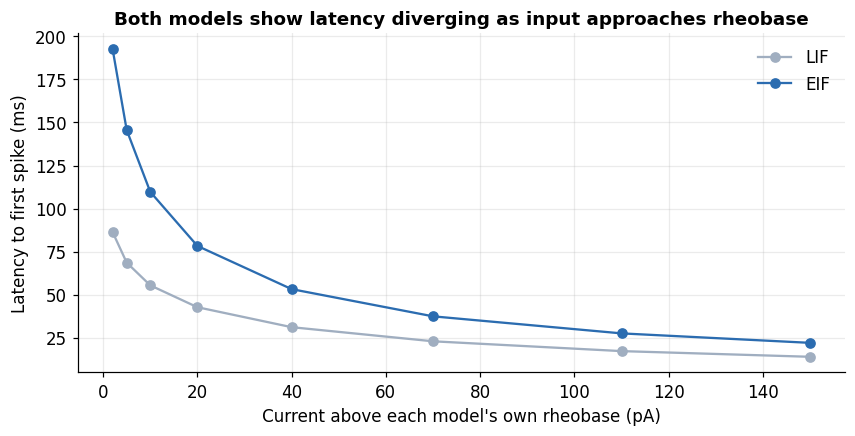

In [5]:
def first_spike_latency(neuron, I, T=500.0):
    neuron.reset_state()
    res = neuron.simulate(I_ext=I, T=T)
    return res["spike_times"][0] if len(res["spike_times"]) else np.nan

I_lif = np.array([152, 155, 160, 170, 190, 220, 260, 300])
I_eif = rheobase_eif_approx + (I_lif - rheobase_lif)  # same *offset above rheobase* for a fair comparison

lat_lif = [first_spike_latency(lif, I) for I in I_lif]
lat_eif = [first_spike_latency(eif, I) for I in I_eif]

fig, ax = plt.subplots()
ax.plot(I_lif - rheobase_lif, lat_lif, "o-", color=COLOR_LIF, label="LIF")
ax.plot(I_eif - rheobase_eif_approx, lat_eif, "o-", color=COLOR_EIF, label="EIF")
ax.set_xlabel("Current above each model's own rheobase (pA)")
ax.set_ylabel("Latency to first spike (ms)")
ax.set_title("Both models show latency diverging as input approaches rheobase")
ax.legend()
plt.show()


## 5. Revisiting Euler vs. RK4 — now with a real nonlinearity

In Notebook 01, LIF's *linear* sub-threshold dynamics meant Euler and RK4 barely disagreed even at dt=1ms. EIF's exponential term changes that. We compare both integrators, at several step sizes, against a very fine-grained (dt=0.005ms) Euler reference.

Reference (dt=0.005ms): 4 spikes at t = [25.9 45.2 64.5 83.8]


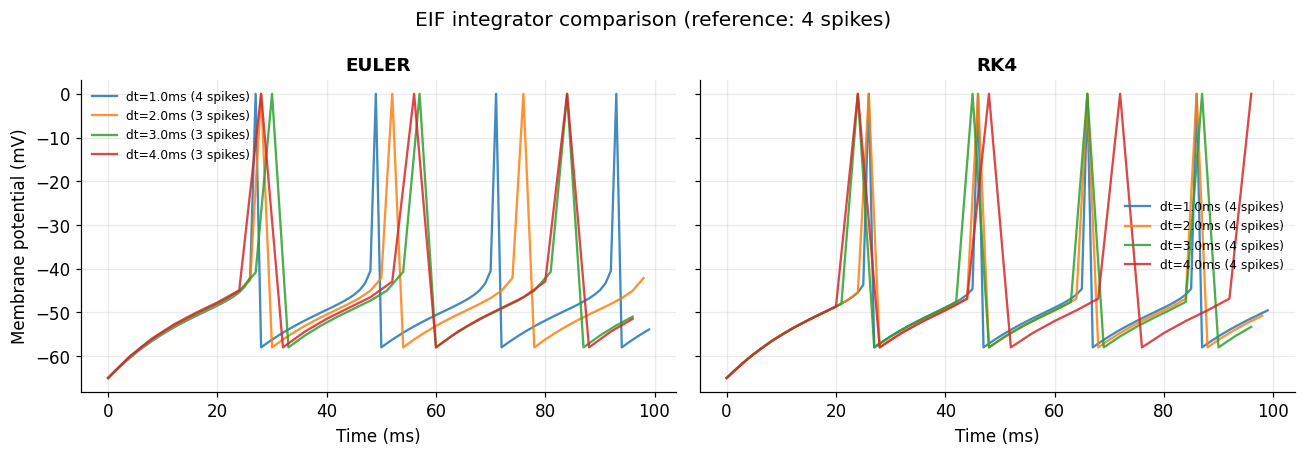

    dt |  Euler spikes |  RK4 spikes
   1.0 |             4 |           4
   2.0 |             3 |           4
   3.0 |             3 |           4
   4.0 |             3 |           4


In [6]:
I_test, T_test = 250.0, 100.0
ref = make_eif(dt=0.005)
ref_res = ref.simulate(I_ext=I_test, T=T_test)
n_ref = len(ref_res["spike_times"])
print(f"Reference (dt=0.005ms): {n_ref} spikes at t = {np.round(ref_res['spike_times'], 1)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
dt_values = [1.0, 2.0, 3.0, 4.0]
for method, ax in zip(["euler", "rk4"], axes):
    for dt in dt_values:
        n = make_eif(dt=dt)
        r = n.simulate(I_ext=I_test, T=T_test, method=method)
        ax.plot(r["t"], r["v"], alpha=0.85, label=f"dt={dt}ms ({len(r['spike_times'])} spikes)")
    ax.set_title(f"{method.upper()}")
    ax.set_xlabel("Time (ms)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Membrane potential (mV)")
fig.suptitle(f"EIF integrator comparison (reference: {n_ref} spikes)")
plt.tight_layout()
plt.show()

print(f"{'dt':>6} | {'Euler spikes':>13} | {'RK4 spikes':>11}")
for dt in dt_values:
    ne = len(make_eif(dt=dt).simulate(I_ext=I_test, T=T_test, method='euler')['spike_times'])
    nr = len(make_eif(dt=dt).simulate(I_ext=I_test, T=T_test, method='rk4')['spike_times'])
    print(f"{dt:>6.1f} | {ne:>13d} | {nr:>11d}")


**Takeaway.** With a genuine nonlinearity, forward Euler's local error accumulates faster: at coarse step sizes it starts *missing spikes entirely* (undercounting relative to the reference), while RK4's four-stage evaluation per step keeps tracking the reference far more faithfully at the same dt. This is precisely the tradeoff `BaseNeuron` is built around — RK4 exists for exactly this kind of single-neuron precision check, while network simulations (Notebook 05) stick to cheap, vectorizable Euler at dt <= 0.1ms, where this error is negligible for any of our models.

## Summary

- The exponential term $g_L \Delta_T e^{(v-v_T)/\Delta_T}$ replaces LIF's hard cutoff with a smooth, accelerating, biophysically-motivated nonlinearity; $\Delta_T \to 0$ recovers something close to a hard threshold.
- Because the exponential current is nonzero even below $v_T$, EIF's effective rheobase sits *below* LIF's, for matched $v_T = v_{th}$.
- Both models are Type I excitable: F-I curves rise continuously from zero, and spike latency diverges as current approaches rheobase from above.
- Euler and RK4 agree closely for LIF (linear) but visibly diverge for EIF (nonlinear) at coarse dt — Euler under-counts spikes at the step sizes we'd never actually use for a network (dt >= 1ms), which is exactly why the project standard stays at dt <= 0.1ms.

**Next:** [03 — The Need for Adaptation (AdEx)](03_The_Need_for_Adaptation_AdEx.ipynb) switches the adaptation current back on and asks what EIF, on its own, still can't explain.
